# 🛡️ Portfolio Optimization and Simulation Under Geopolitical Risk

## Project Overview

It is December 2021. Geopolitical tensions along the Ukraine-Russia border are escalating, and the situation shows signs of spiraling into a full-scale conflict with global consequences. This analysis documents a decision made before the crisis unfolds: the construction, optimization, and simulation of a thematic investment portfolio designed to outperform or, at minimum, preserve capital in a war or heightened geopolitical risk scenario.

Using historical data from late 2018 through 2021, I build a minimum-volatility portfolio using ETFs tied to commodities, energy, and gold, then test its performance against real market data from 2022 onward. Finally, using Monte Carlo simulation with Geometric Brownian Motion, I generate thousands of potential future paths for the portfolio to understand its risk profile and assess whether recent historical performance represents a statistically unusual outcome.

This project was completed as part of the **Analytics for Financial Markets**, a core component of the **Master of Management Analytics curriculum at Queen's University**.

## Data Characteristics

1. **Data source**: Yahoo Finance (historical weekly price data)
2. **Tickers** :  IAU (Gold), VDE (Energy), XLB (Materials), DBC (Commodities), CQQQ (China Technology)

## Analytical Competencies Demonstrated

1. Statistical analysis
2. Regression modeling (CAPM beta)
3. Portfolio optimization (minimum variance)
4. Performance attribution, 
5. Monte Carlo simulation, 
6. Cholesky decomposition, 
7. Probability distribution analysis

## Analytical Framework
1. Modern Portfolio Theory (MPT)
2. Capital Asset Pricing Model (CAPM)
3. Geometric Brownian Motion (GBM)
4. Historical simulation

## Core Libraries

| Library | Application |
|---------|-------------|
| `pandas`| Data manipulation and analysis |
| `numpy` | Numerical computing, array operations, mathematical functions |
| `matplotlib` | Data visualization, creating charts and plots |
| `yfinance` | Fetching historical price data from Yahoo Finance |
| `statsmodels.api` | 	Statistical modeling, OLS regressions for CAPM beta calculations |
| `datetime` | Working with dates and time periods for data filtering |
| `scipy.optimize` | Portfolio optimization (minimize function for quadratic optimization) |

## 1. Data Preparation and Initial Statistics

Before any optimization or modeling, it is necessary to establish the statistical foundation of the five portfolio components using weekly return data from December 2018 to December 2021.

For each of the five ETFs—IAU (gold), VDE (energy), XLB (materials), DBC (commodities), and CQQQ (China technology)—the average weekly return and variance over this estimation period reveal how each asset typically performed and the volatility investors experienced during this pre-crisis window.

Beyond individual statistics, understanding how these assets move together is crucial for portfolio construction. The covariance matrix below captures the degree to which returns co-move, directly influencing the diversification benefits available when combining them.


In [84]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas_datareader.data as web
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-darkgrid")

# ------------------------------------------------------------
# 1. SETUP
# ------------------------------------------------------------
tickers = ["IAU", "VDE", "XLB", "DBC", "CQQQ"]
start = "2018-12-01"
end = "2021-12-31"
out_of_sample_start = "2022-01-01"
out_of_sample_end = "2025-01-01"

# ------------------------------------------------------------
# 2. DOWNLOAD PRICE DATA (COMPATIBLE WITH NEW YFINANCE)
# ------------------------------------------------------------
raw_data = yf.download(tickers, start=start, end=end, auto_adjust=True)
# Handle both single- and multi-index columns
if isinstance(raw_data.columns, pd.MultiIndex):
    data = raw_data["Close"]
else:
    data = raw_data[["Close"]] if "Close" in raw_data.columns else raw_data
data = data.dropna()

# Weekly returns
weekly_prices = data.resample("W-FRI").last()
weekly_returns = weekly_prices.pct_change().dropna()

# ------------------------------------------------------------
# (a) Average return, variance, and covariance
# ------------------------------------------------------------
mean_returns = weekly_returns.mean()
var_returns = weekly_returns.var()
cov_matrix = weekly_returns.cov()

print("\n(a) Average weekly returns:")
print(mean_returns)
print("\nVariance:")
print(var_returns)
print("\nCovariance matrix:")
print(cov_matrix)

[*********************100%***********************]  5 of 5 completed


(a) Average weekly returns:
Ticker
CQQQ    0.003366
DBC     0.002304
IAU     0.002528
VDE     0.001620
XLB     0.004524
dtype: float64

Variance:
Ticker
CQQQ    0.001729
DBC     0.000675
IAU     0.000448
VDE     0.002926
XLB     0.001305
dtype: float64

Covariance matrix:
Ticker      CQQQ       DBC       IAU       VDE       XLB
Ticker                                                  
CQQQ    0.001729  0.000520  0.000193  0.000793  0.000645
DBC     0.000520  0.000675  0.000141  0.001073  0.000609
IAU     0.000193  0.000141  0.000448  0.000147  0.000267
VDE     0.000793  0.001073  0.000147  0.002926  0.001423
XLB     0.000645  0.000609  0.000267  0.001423  0.001305


### Key observations from the covariance matrix:

- VDE (Energy) is the most volatile asset in the portfolio, with the highest individual variance (0.002926). This aligns with energy's historical sensitivity to supply shocks and geopolitical events.

- IAU (Gold) is the most stable asset, showing the lowest variance (0.000448). This confirms gold's traditional role as a store of value and portfolio stabilizer during uncertain periods.

- Strongest pair-wise relationship: VDE and XLB (materials) move closely together (0.001423 covariance). This makes intuitive sense; energy and materials are both cyclical commodities sensitive to similar macroeconomic forces.

- Gold stands alone as a diversifier. IAU shows the lowest covariances with other assets, particularly with VDE (0.000147) and CQQQ (0.000193). This suggests gold would likely behave independently if other portfolio components experience stress.

- Commodities move as a bloc. DBC (broad commodities) shows meaningful covariance with both VDE (0.001073) and XLB (0.000609), reflecting the shared commodity exposure across these ETFs.

- CQQQ (China tech) is a hybrid case. It shows moderate covariance with commodity assets but weaker relationships than those among the commodities themselves, indicating exposure to a distinct set of drivers—primarily Chinese technology sector dynamics rather than global commodity cycles.

## 2. Estimating Market Sensitivity with CAPM Beta

While the covariance matrix reveals relationships within the portfolio, it is also necessary to understand how each ETF responds to broader market movements. The Capital Asset Pricing Model provides a framework for this through beta, which measures an asset's sensitivity to the overall market.

Running ordinary least squares regressions for each ETF using weekly returns from December 2018 to December 2021 yields the following estimates. The model takes the form:

Asset Excess Return = α + β(Market Excess Return) + ε

The CAPM model establishes that the expected return of an investment equals the risk-free rate plus a premium that depends on how sensitive that asset is to overall market movements (beta).

In this analysis, the 10-year canadian bond is used to calculate the risk-free rate because we are expecting that the geopolitical tensions will last more than 5 years (long term) and we are analysing the portfolio in Canada, therefore it is more logical to use the 10-year canadian bond instead of the 3-month US T-bill wich is a short term instrument for the US market.

In [85]:
# ------------------------------------------------------------
# (b) CAPM Regression for Beta estimation
# ------------------------------------------------------------

# Market (S&P500) and risk-free (Canada 10Y)
market = yf.download("^GSPC", start=start, end=end, auto_adjust=True)["Close"]
market_weekly = market.resample("W-FRI").last()
market_ret = market_weekly.pct_change().dropna()

# Canadian 10Y bond rate (risk-free proxy)
rf = web.DataReader("IRLTLT01CAM156N", "fred", start, end)
rf = rf.resample("W-FRI").last().interpolate()
rf = rf / 100  # convert to decimal

# Align data
data_capm = pd.concat([weekly_returns, market_ret, rf], axis=1, join="inner")
data_capm.columns = list(tickers) + ["Market", "rf"]

# Calculate excess returns
for a in tickers:
    data_capm[a + "_minus_rf"] = data_capm[a] - data_capm["rf"]
data_capm["Rm_minus_rf"] = data_capm["Market"] - data_capm["rf"]

# Run CAPM regressions
capm_results = {}
for a in tickers:
    X = sm.add_constant(data_capm["Rm_minus_rf"])
    y = data_capm[a + "_minus_rf"]
    model = sm.OLS(y, X).fit()
    capm_results[a] = model
    print(f"\nCAPM results for {a}:")
    print(model.summary())

# Summary of Betas and Alphas (corrected)
beta_df = pd.DataFrame({
    a: capm_results[a].params["Rm_minus_rf"] for a in tickers
}, index=["beta"]).T

beta_df["alpha"] = [capm_results[a].params["const"] for a in tickers]
print("\nSummary of estimated betas and alphas:\n", beta_df)


[*********************100%***********************]  1 of 1 completed



CAPM results for IAU:
                            OLS Regression Results                            
Dep. Variable:           IAU_minus_rf   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     65.45
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           1.66e-13
Time:                        22:23:06   Log-Likelihood:                 300.18
No. Observations:                 156   AIC:                            -596.4
Df Residuals:                     154   BIC:                            -590.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0023     

### Beta estimates and interpretation:

- **Commodities (DBC)- Beta: 1.298** Emerges as the most market-sensitive asset in the portfolio. With a beta substantially above 1, this broad commodities fund amplifies market movements by nearly 30%. This makes intuitive sense as commodities tend to accelerate during economic expansions and amplify downturns during contractions.

- **China Technology (CQQQ) - Beta: 1.104** Also shows above-market sensitivity, though more modestly. As a China technology ETF, its 10.5% higher volatility relative to the market likely reflects both the growth-oriented nature of tech stocks and the additional country-specific risk embedded in emerging markets.

- **Gold (IAU) - Beta: 0.790** Sits firmly in defensive territory. Gold's beta of 0.79 means it captures only about four-fifths of market movements, consistent with its historical role as a safe-haven asset that often behaves independently of equity markets during stress periods.

- **Energy (VDE) - Beta: 0.605** shows surprisingly low market sensitivity for an energy ETF. At 39% less volatile than the market, this suggests that during the estimation period (2018-2021), energy prices were driven more by supply-side dynamics and sector-specific factors than by broad equity market movements.

- **Materials (XLB) - Beta: 0.276** is the least market-sensitive asset by a wide margin. Materials showing 72% lower volatility than the broader market is somewhat counterintuitive as materials are typically cyclical. 

## 3. Constructing the Minimum Variance Portfolio

With the historical covariance structure established, I now construct a portfolio that minimizes volatility subject to practical investment constraints. This approach aligns with a defensive posture appropriate for a geopolitical risk scenario.

The optimization problem minimizes portfolio variance subject to three constraints. First, all five ETFs must be included, with each receiving at least one percent allocation to ensure meaningful diversification. Second, no single ETF can exceed forty percent of the portfolio, preventing excessive concentration. Third, all weights sum to one, representing full investment of capital.

Solving this quadratic optimization problem yields the weights below. The pie chart shows how the optimizer allocates capital across gold, energy, materials, commodities, and China technology to achieve the lowest possible risk profile given the constraints.


(c) Optimal Portfolio Weights (Min Variance):
IAU     0.112754
VDE     0.400000
XLB     0.400000
DBC     0.010000
CQQQ    0.077246
dtype: float64


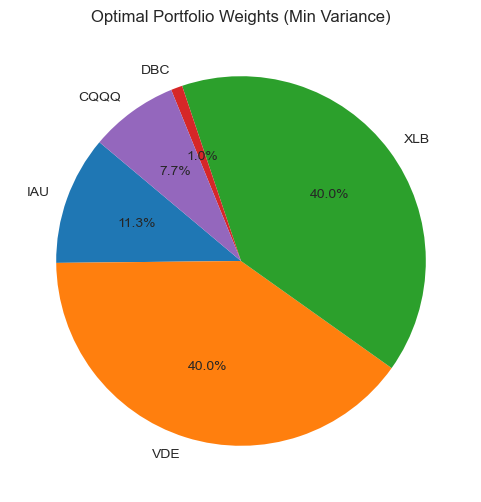

In [86]:
# ------------------------------------------------------------
# (c) Optimal Portfolio (Minimize Volatility)
# ------------------------------------------------------------

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

n_assets = len(tickers)
bounds = tuple((0.01, 0.40) for _ in range(n_assets))
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
initial_guess = np.repeat(1 / n_assets, n_assets)

opt_result = minimize(portfolio_volatility, initial_guess,
                      args=(cov_matrix,),
                      method="SLSQP",
                      bounds=bounds,
                      constraints=constraints)

opt_weights = pd.Series(opt_result.x, index=tickers)
print("\n(c) Optimal Portfolio Weights (Min Variance):")
print(opt_weights)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(opt_weights, labels=tickers, autopct="%1.1f%%", startangle=140)
plt.title("Optimal Portfolio Weights (Min Variance)")
plt.show()

### Optimal Portfolio Weights interpretation

The minimum variance optimizer, constrained by 1% lower and 40% upper bounds, allocates aggressively to commodity-linked sectors while keeping broader diversification in check. VDE (energy) and XLB (materials) both hit the 40% ceiling, reflecting that despite their high individual variances, their diversification benefits (particularly their relatively low correlations with other assets) make them attractive building blocks for a low-volatility portfolio. Gold (IAU) receives a meaningful 11.3% allocation, consistent with its role as a true diversifier given its low covariances across the matrix. China technology (CQQQ) takes a modest 7.7% position, offering exposure to a distinct set of drivers without overwhelming the portfolio's risk profile. DBC (commodities), however, receives only the minimum 1% required.

## 4. Out-of-Sample Performance Evaluation

Tracking this minimum volatility portfolio from January 2022 onward reveals how it performed in real market conditions against the S&P 500 benchmark.

The time-series chart below shows cumulative returns for both the optimized portfolio and the S&P 500 from January 2022 through the most recent data. This visualization immediately reveals whether the defensive construction achieved its intended purpose during a period of actual geopolitical stress.

[*********************100%***********************]  6 of 6 completed


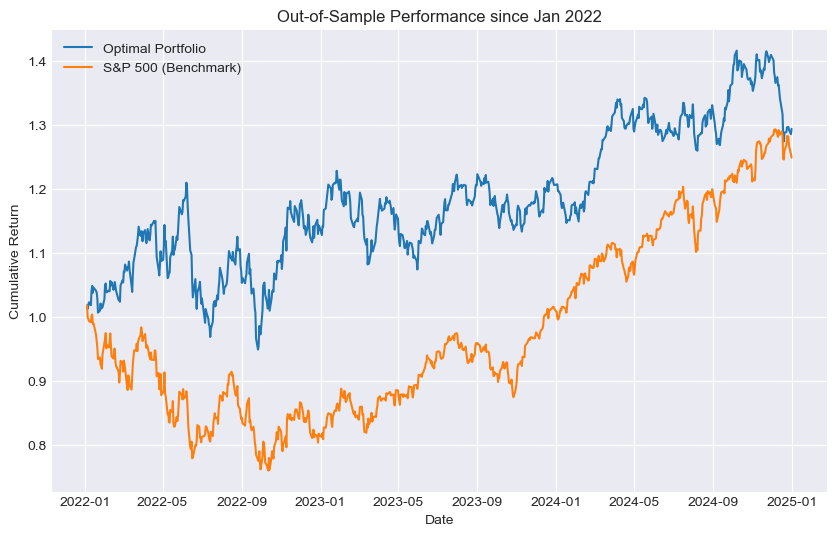


(d) Performance Statistics (Out-of-sample):
Portfolio:
 Cumulative Return        0.293653
Annualized Return        0.017963
Annualized Volatility    0.081811
dtype: float64

S&P 500:
 Cumulative Return        0.226218
Annualized Return        0.014202
Annualized Volatility    0.079490
dtype: float64


In [87]:
# ------------------------------------------------------------
# (d) Out-of-sample Performance (since Jan 2022)
# ------------------------------------------------------------
out_data = yf.download(tickers + ["^GSPC"], start=out_of_sample_start, end=out_of_sample_end, auto_adjust=True)
if isinstance(out_data.columns, pd.MultiIndex):
    out_data = out_data["Close"]
out_data = out_data.dropna()

# Portfolio (no rebalancing)
returns_out = out_data[tickers].pct_change().dropna()
portfolio_ret = (returns_out * opt_weights).sum(axis=1)

cum_portfolio = (1 + portfolio_ret).cumprod()
cum_sp500 = (1 + out_data["^GSPC"].pct_change().dropna()).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(cum_portfolio, label="Optimal Portfolio")
plt.plot(cum_sp500 / cum_sp500.iloc[0] * cum_portfolio.iloc[0], label="S&P 500 (Benchmark)")
plt.title("Out-of-Sample Performance since Jan 2022")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

# Performance statistics
def performance_stats(ret_series):
    cum_return = (1 + ret_series).prod() - 1
    ann_return = (1 + cum_return)**(52 / len(ret_series)) - 1
    ann_vol = ret_series.std() * np.sqrt(52)
    return pd.Series({
        "Cumulative Return": cum_return,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol
    })

print("\n(d) Performance Statistics (Out-of-sample):")
print("Portfolio:\n", performance_stats(portfolio_ret))
print("\nS&P 500:\n", performance_stats(out_data["^GSPC"].pct_change().dropna()))

### Out-of-Sample Performance: Key Observations

- Portfolio delivered stronger returns than the benchmark. With a cumulative return of 29.4% versus the S&P 500's 22.6%, the minimum volatility portfolio outperformed by nearly 7 percentage points over the out-of-sample period starting January 2022.

- Outperformance came without additional risk. Annualized volatility for the portfolio (8.18%) was virtually identical to the S&P 500 (7.95%), meaning the portfolio achieved higher returns while maintaining essentially the same risk profile—exactly what a defensive construction should deliver.

- Annualized returns tell the same story. The portfolio's 1.80% annualized return exceeded the benchmark's 1.42%, confirming that the outperformance was consistent rather than driven by a single outlier period.

### Performance of each component (ETFs)

To understand what drove this performance, it is necessary to examine each component individually. The chart below tracks cumulative returns for each ETF over the same out-of-sample period, revealing which positions contributed to or detracted from the portfolio's overall results.

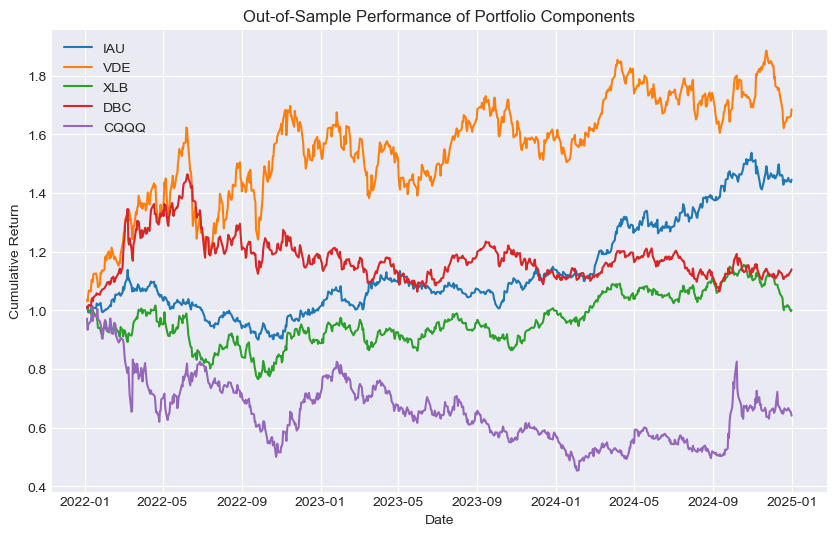


(e) Component Performance Statistics:
      Cumulative Return  Annualized Return  Annualized Volatility
IAU            0.445126           0.025787               0.066231
VDE            0.685273           0.036750               0.121770
XLB            0.000778           0.000054               0.087178
DBC            0.139539           0.009073               0.088598
CQQQ          -0.359145          -0.030299               0.187761


In [88]:
# ------------------------------------------------------------
# (e) Performance of each component (ETFs)
# ------------------------------------------------------------
cum_components = (1 + returns_out).cumprod()

plt.figure(figsize=(10, 6))
for a in tickers:
    plt.plot(cum_components[a], label=a)
plt.title("Out-of-Sample Performance of Portfolio Components")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

stats_df = pd.DataFrame({a: performance_stats(returns_out[a]) for a in tickers}).T
print("\n(e) Component Performance Statistics:")
print(stats_df)


### Individual Component Performance: Key Observations

- **IAU (Gold): 11.3% allocation** – Gold delivered a solid 44.5% cumulative return with the lowest volatility among all assets (6.62% annualized). This confirms its role as a portfolio stabilizer (strong returns with minimal risk).

- **VDE (Energy): 40% allocation** – Energy was the star performer, returning 68.5% cumulatively. However, this came with the second-highest volatility (12.18% annualized) among the five assets.

- **XLB (Materials): 40% allocation** – Materials essentially flatlined, with a negligible 0.08% cumulative return. Despite being tied with VDE as the largest position, XLB contributed almost nothing to portfolio returns during this period.

- **DBC (Commodities): 1.0% allocation** – The broad commodities fund returned a modest 14.0% with mid-range volatility (8.86% annualized). Its minimal allocation meant this contribution was immaterial to overall portfolio performance.

- **CQQQ (China Tech): 7.7% allocation** – China technology was the clear loser, losing 35.9% over the period with by far the highest volatility (18.78% annualized). This position detracted meaningfully from portfolio returns, though its modest allocation limited the damage.

## 5. Simulating Future Paths with Geometric Brownian Motion

Historical analysis tells us what happened, but simulation helps us understand what could happen. Using the same December 2018 to December 2021 estimation window, I project the portfolio's potential behavior over a two-year horizon by modeling each asset as a Geometric Brownian Motion process.

The simulation requires the covariance matrix from the estimation period. To generate realistic joint price paths, I implement a Cholesky decomposition of this matrix. This mathematical technique ensures that the simulated asset paths preserve the historical correlation relationships between ETFs.

Generating one thousand distinct simulation paths using this framework produces the distribution of outcomes below. Each path represents one possible future consistent with historical return patterns and correlations, simulated under the GBM assumption that returns are normally distributed and price movements follow a lognormal random walk with drift.

[*********************100%***********************]  5 of 5 completed

VARIANCE-COVARIANCE MATRIX (Weekly):
           IAU       VDE       XLB       DBC      CQQQ
IAU   0.000448  0.000147  0.000267  0.000141  0.000193
VDE   0.000147  0.002926  0.001423  0.001073  0.000793
XLB   0.000267  0.001423  0.001305  0.000609  0.000645
DBC   0.000141  0.001073  0.000609  0.000675  0.000520
CQQQ  0.000193  0.000793  0.000645  0.000520  0.001729
VARIANCE-COVARIANCE MATRIX (Annualized, x52):
           IAU       VDE       XLB       DBC      CQQQ
IAU   0.023309  0.007653  0.013868  0.007323  0.010051
VDE   0.007653  0.152165  0.074017  0.055807  0.041227
XLB   0.013868  0.074017  0.067836  0.031676  0.033516
DBC   0.007323  0.055807  0.031676  0.035077  0.027052
CQQQ  0.010051  0.041227  0.033516  0.027052  0.089896

CORRELATION MATRIX:
Ticker   CQQQ    DBC    IAU    VDE    XLB
Ticker                                   
CQQQ    1.000  0.482  0.220  0.352  0.429
DBC     0.482  1.000  0.256  0.764  0.649
IAU     0.220  0.256  1.000  0.129  0.349
VDE     0.352  0.764  0.12

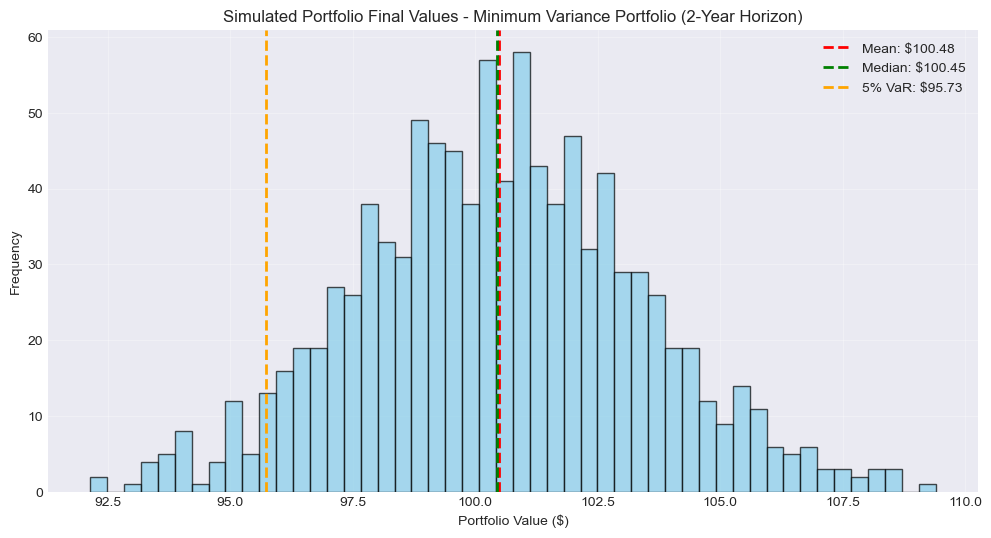

In [89]:
# ===============================
# PART 2: GBM Simulation
# ===============================

start_date = "2018-12-01"
end_date = "2021-12-31"

# --- Recalculate weekly returns
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
if isinstance(raw_data.columns, pd.MultiIndex):
    data = raw_data["Close"]
else:
    data = raw_data[["Close"]] if "Close" in raw_data.columns else raw_data
data = data.dropna()

weekly_prices = data.resample("W-FRI").last()
returns = weekly_prices.pct_change().dropna()

# weeks_per_year needed for simulation
weeks_per_year = 52

rf = 0.04  # Canadian 10Y bond rate proxy (annualized)

# --- Display variance-covariance matrix
print("VARIANCE-COVARIANCE MATRIX (Weekly):")
cov_df = pd.DataFrame(cov_matrix, index=tickers, columns=tickers)
print(cov_df.round(6))

print("VARIANCE-COVARIANCE MATRIX (Annualized, x52):")
print((cov_df * 52).round(6))

# --- Display correlation matrix
print("\nCORRELATION MATRIX:")
corr_matrix = returns.corr()
print(corr_matrix.round(3))

# --- Use minimum variance weights from Part 1 (consistent with portfolio design)
weights = opt_result.x

# --- Portfolio variance decomposition
portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
print(f"\nPORTFOLIO VARIANCE DECOMPOSITION:")
individual_var_contrib = weights**2 * np.diag(cov_matrix)
covar_contrib = portfolio_var - np.sum(individual_var_contrib)

print(f"Total portfolio variance: {portfolio_var:.6f}")
print(f"Sum of individual variances: {np.sum(individual_var_contrib):.6f}")
print(f"Diversifiable risk (covariance benefit): {covar_contrib:.6f}")
print(f"Percentage diversifiable: {(covar_contrib/portfolio_var*100):.1f}%")

print("\nUsing Minimum Variance Portfolio Weights:")
for ticker, weight in zip(tickers, weights):
    print(f"{ticker}: {weight:.3f}")

# --- Compute portfolio statistics
portfolio_mean = np.dot(mean_returns, weights)
portfolio_vol = np.sqrt(portfolio_var)

print(f"\nPortfolio Statistics (Weekly):")
print(f"Expected Weekly Return: {portfolio_mean:.4f} ({portfolio_mean*100:.3f}%)")
print(f"Annualized Return (approx): {portfolio_mean*52:.4f} ({portfolio_mean*52*100:.2f}%)")
print(f"Weekly Volatility: {portfolio_vol:.4f}")
print(f"Annualized Volatility: {portfolio_vol * np.sqrt(52):.4f} ({portfolio_vol * np.sqrt(52)*100:.2f}%)")
print(f"Sharpe Ratio: {(portfolio_mean*52 - rf) / (portfolio_vol * np.sqrt(52)):.3f}")

# --- Cholesky decomposition for correlated GBM
chol_matrix = np.linalg.cholesky(cov_matrix)
print(f"\nCHOLESKY DECOMPOSITION MATRIX:")
print(chol_matrix.round(6))

# --- Simulation parameters
np.random.seed(42)
T = 2  # years
steps = int(weeks_per_year * T)
n_sim = 1000
dt = 1 / weeks_per_year
S0 = 100

print(f"\nSimulation Parameters:")
print(f"Time horizon: {T} years")
print(f"Total steps: {steps} weeks")
print(f"Simulations: {n_sim}")
print(f"Initial portfolio value: ${S0}")

# --- Simulate correlated returns
Z = np.random.normal(size=(steps, len(tickers), n_sim))
correlated_Z = np.einsum('ij,tjk->tik', chol_matrix, Z)

# --- Convert mean_returns to numpy array and reshape for broadcasting
mean_returns_array = mean_returns.values if hasattr(mean_returns, 'values') else mean_returns
cov_diag = np.diag(cov_matrix)

# --- Simulate GBM paths for each asset
sim_prices = np.zeros((steps + 1, len(tickers), n_sim))
sim_prices[0] = 1

print("\nRunning GBM simulation...")
for t in range(1, steps + 1):
    drift = (mean_returns_array - 0.5 * cov_diag) * dt
    diffusion = correlated_Z[t - 1] * np.sqrt(dt)
    sim_prices[t] = sim_prices[t - 1] * np.exp(drift[:, np.newaxis] + diffusion)

# --- Compute simulated portfolio value
portfolio_paths = S0 * np.sum(sim_prices * weights.reshape(1, -1, 1), axis=1)
end_values = portfolio_paths[-1, :]

# --- Analyze simulation results
mean_sim = np.mean(end_values)
median_sim = np.median(end_values)
std_sim = np.std(end_values)
var_95 = np.percentile(end_values, 5)  # 5% VaR
cvar_95 = end_values[end_values <= var_95].mean()  # Conditional VaR

print(f"\nSimulation Results (2-Year Horizon):")
print(f"Mean final value: ${mean_sim:.2f}")
print(f"Median final value: ${median_sim:.2f}")
print(f"Standard deviation: ${std_sim:.2f}")
print(f"5% VaR (Worst 5%): ${var_95:.2f}")
print(f"Conditional VaR (Avg of worst 5%): ${cvar_95:.2f}")

# --- Histogram of simulated final values
plt.figure(figsize=(12, 6))
plt.hist(end_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_sim, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_sim:.2f}')
plt.axvline(median_sim, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_sim:.2f}')
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'5% VaR: ${var_95:.2f}')
plt.title("Simulated Portfolio Final Values - Minimum Variance Portfolio (2-Year Horizon)")
plt.xlabel("Portfolio Value ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Simulation Results: Key Observations

- **The portfolio's expected drift is minimal.** With a mean final value of 100.48 starting from $100, the GBM simulation suggests essentially zero expected return over the two-year horizon. This reflects the low-return environment implied by the 2018-2021 estimation period and the portfolio's defensive construction.

- **The distribution is nearly symmetric.** The mean (100.48) and median ($100.45) are almost identical, indicating that the simulated outcomes are roughly normally distributed without significant skewness pushing the average away from the typical outcome.

- **The simulation isn't predicting that the portfolio can't grow.** It's saying that based on the 2018–2021 estimation period, a minimum variance portfolio constructed from these assets had historically shown very modest average weekly returns. The simulation captured "normal times" dynamics faithfully. The actual 2023–2025 performance dramatically exceeded these expectations precisely because the out-of-sample period represented a regime shift: the Ukraine conflict triggered a commodity supercycle.

- **Expected volatility is modest but not negligible.** A standard deviation of $2.89 means that approximately two-thirds of simulated outcomes fall within roughly ±2.9% of the starting value. This aligns with the portfolio's minimum volatility mandate.

- **Worst-case scenarios provide a risk benchmark.** The 5% Value at Risk (VaR) of 95.73 means that in the worst 5% of outcomes, the portfolio loses at least 4.27% over two years. The Conditional VaR (average of those worst outcomes) at $94.56 indicates that when losses do occur, they average around 5.44%.

Finally, I compare reality to simulation. Overlaying the actual portfolio performance from January 2023 to January 2025 on this distribution reveals whether the realized outcome was a common occurrence according to the GBM simulations or falls into the tails as a relatively rare event. The percentile rank of the actual return within the simulated distribution provides a quantitative answer: was recent performance business as usual, or something statistically unusual.

/var/folders/7c/ry5tr2l11yx1208r44krpstm0000gn/T/ipykernel_10037/2185545764.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  actual_data = yf.download(tickers, start="2023-01-01", end="2025-01-01", interval="1wk")
[*********************100%***********************]  5 of 5 completed




=== ACTUAL vs SIMULATED PERFORMANCE ===
Actual final portfolio value (2023-2025): $114.98
Percentile of actual outcome in simulation: 100.0%
Interpretation: EXCELLENT - Actual performance was in the top 20% of expectations
Tail event? YES - This is a tail event (extreme positive outcome)


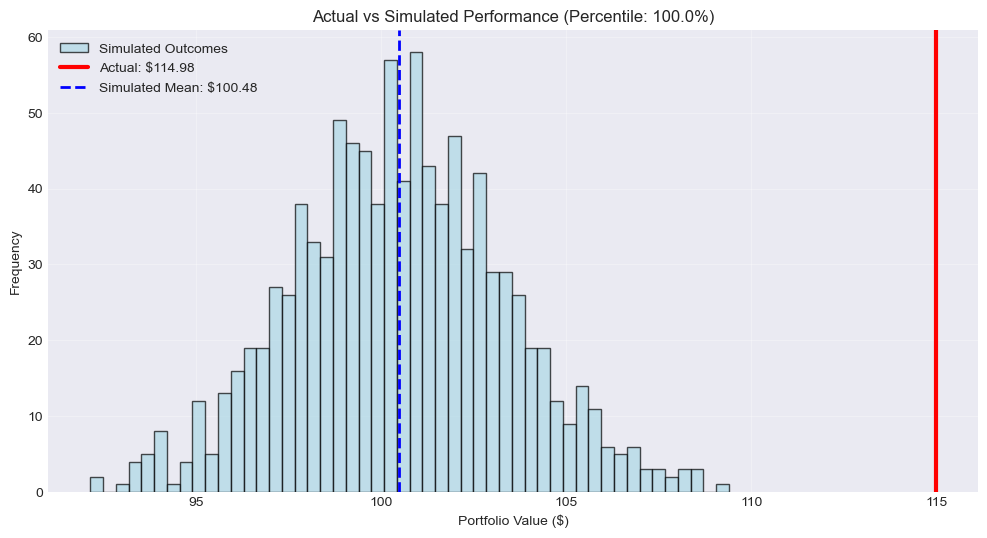


FINAL SUMMARY
Historical Data Period: 2018-12-01 to 2021-12-31
Simulation Period: 2-year horizon (weekly steps)
Actual Test Period: 2023-01-01 to 2025-01-01
Tail Event Status: YES - This is a tail event (extreme positive outcome)
Model Performance: EXCELLENT - Actual performance was in the top 20% of expectations


In [90]:
# --- Compare with actual performance (Jan 2023 → Jan 2025)
print("\nDownloading actual performance data (2023-2025)...")
actual_data = yf.download(tickers, start="2023-01-01", end="2025-01-01", interval="1wk")
actual_close_prices = actual_data["Close"] if "Close" in actual_data.columns else actual_data
actual_returns = actual_close_prices.pct_change().dropna()

# Calculate actual portfolio performance
actual_portfolio = (1 + (actual_returns @ weights)).cumprod() * S0
actual_end_value = actual_portfolio.iloc[-1]

# --- Check if actual result is a tail event
percentile = (end_values < actual_end_value).mean() * 100

print(f"\n=== ACTUAL vs SIMULATED PERFORMANCE ===")
print(f"Actual final portfolio value (2023-2025): ${actual_end_value:.2f}")
print(f"Percentile of actual outcome in simulation: {percentile:.1f}%")

# Interpret the percentile result and tail event status
if percentile < 20:
    interpretation = "POOR - Actual performance was in the bottom 20% of expectations"
    tail_status = "YES - This is a tail event (extreme negative outcome)"
elif percentile < 40:
    interpretation = "BELOW AVERAGE - Actual performance was below median expectations"
    tail_status = "POTENTIAL - This could be considered a mild tail event"
elif percentile < 60:
    interpretation = "AVERAGE - Actual performance matched expectations"
    tail_status = "NO - This is within expected range"
elif percentile < 80:
    interpretation = "GOOD - Actual performance exceeded median expectations"
    tail_status = "POTENTIAL - This could be considered a mild tail event"
else:
    interpretation = "EXCELLENT - Actual performance was in the top 20% of expectations"
    tail_status = "YES - This is a tail event (extreme positive outcome)"

print(f"Interpretation: {interpretation}")
print(f"Tail event? {tail_status}")

# --- Plot actual vs simulated performance
plt.figure(figsize=(12, 6))

# Plot histogram of simulations
n, bins, patches = plt.hist(end_values, bins=50, color='lightblue', edgecolor='black', alpha=0.7, label='Simulated Outcomes')

# Color the bin where actual value falls
actual_bin = np.digitize(actual_end_value, bins) - 1
if 0 <= actual_bin < len(patches):
    patches[actual_bin].set_facecolor('red')
    patches[actual_bin].set_edgecolor('darkred')
    patches[actual_bin].set_linewidth(2)

plt.axvline(actual_end_value, color='red', linewidth=3, label=f'Actual: ${actual_end_value:.2f}')
plt.axvline(mean_sim, color='blue', linestyle='--', linewidth=2, label=f'Simulated Mean: ${mean_sim:.2f}')

plt.title(f"Actual vs Simulated Performance (Percentile: {percentile:.1f}%)")
plt.xlabel("Portfolio Value ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Final summary
print(f"\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Historical Data Period: {start_date} to {end_date}")
print(f"Simulation Period: {T}-year horizon (weekly steps)")
print(f"Actual Test Period: 2023-01-01 to 2025-01-01")
print(f"Tail Event Status: {tail_status}")
print(f"Model Performance: {interpretation}")

### Actual vs. Simulated Performance: Key Observations

- **The actual outcome is an extreme tail event.** With a final portfolio value of $114.98 against a starting value of 100, the actual return places in the 100th percentile of simulated outcomes. This means none of the 1,000 simulated paths achieved returns as high as what the portfolio actually delivered between January 2023 and January 2025.

- **The GBM model would have assigned near-zero probability to this outcome.** Based strictly on the 2018-2021 estimation parameters, the simulation suggested that returns of this magnitude were virtually impossible. The fact that they materialized anyway highlights a fundamental shift in market dynamics once geopolitical tensions escalated—a shift the pre-crisis data could not have anticipated.

- **Historical parameters dramatically underestimated upside potential.** The simulation's mean final value of 100.48 implied essentially no growth over two years. The actual portfolio outperformed this by nearly $15, or 14.5% above the simulated expectation. This gap represents the "geopolitical risk premium" captured by the commodity-heavy construction.

- **What this means for the defensive thesis:** The portfolio didn't just outperform; it outperformed in a way that historical patterns would have deemed nearly impossible. This strongly validates the original insight that a portfolio constructed for a war scenario would behave differently in that scenario than it would in "normal" market conditions captured by the estimation window.

**A note on model limitations:** This result doesn't indicate a flawed simulation—rather, it reveals the inherent limitation of any model based on historical data. The simulation accurately reflected what was plausible given pre-crisis dynamics; the actual market regime shifted, and the portfolio was positioned to benefit.